Weekly revenue is modeled as the sum of baseline demand, trend, promotion, yearly seasonality, and channel-specific media contributions after geometric adstock and logistic saturation.

$$ y_t \sim \mathcal{N}(\mu_t, \sigma) $$

$$ \mu_t = \alpha + \gamma_1 \,\text{promotion}_t + \gamma_2 \,\text{time\_index}_t +\text{seasonality}_t+ \sum_{m=1}^{3} \beta_m S_{\lambda_m} \left( A_{\alpha_m}(x_{t,m}) \right) $$

In [1]:
%pip install -U ipywidgets


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

from pymc_marketing.mmm import (GeometricAdstock, LogisticSaturation,)
from pymc_marketing.mmm.multidimensional import MMM

RANDOM_SEED = 20260801

train_df = pd.read_csv( "../data/scenario_a/scenario_a_train.csv", parse_dates=["date_week"],)

channel_columns = [ "tv_spend",   "google_search_spend",  "tiktok_spend", ]
control_columns = [  "promotion", "time_index", ]

X_train = train_df[ ["date_week", *channel_columns,  *control_columns, ] ].copy()
y_train = train_df["revenue"].copy()

mmm = MMM(
    date_column="date_week",
    target_column="revenue",
    channel_columns=channel_columns,
    control_columns=control_columns,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)
mmm

l_max is a structural modeling choice rather than a parameter estimated by NUTS. The decay parameter is inferred from the data conditional on that maximum lag. I would choose a defensible baseline using domain knowledge, then compare alternative lag windows through time-based validation, residual diagnostics, and sensitivity analysis.

In [7]:
mmm.build_model(
    X=X_train,
    y=y_train,
)

print(mmm.model)

print("Coordinates:")
display(mmm.model.coords)

print("Named variables:")
for variable_name in mmm.model.named_vars:
    print(variable_name)

Coordinates:


{'date': (np.datetime64('2023-01-02T00:00:00.000000'),
  np.datetime64('2023-01-09T00:00:00.000000'),
  np.datetime64('2023-01-16T00:00:00.000000'),
  np.datetime64('2023-01-23T00:00:00.000000'),
  np.datetime64('2023-01-30T00:00:00.000000'),
  np.datetime64('2023-02-06T00:00:00.000000'),
  np.datetime64('2023-02-13T00:00:00.000000'),
  np.datetime64('2023-02-20T00:00:00.000000'),
  np.datetime64('2023-02-27T00:00:00.000000'),
  np.datetime64('2023-03-06T00:00:00.000000'),
  np.datetime64('2023-03-13T00:00:00.000000'),
  np.datetime64('2023-03-20T00:00:00.000000'),
  np.datetime64('2023-03-27T00:00:00.000000'),
  np.datetime64('2023-04-03T00:00:00.000000'),
  np.datetime64('2023-04-10T00:00:00.000000'),
  np.datetime64('2023-04-17T00:00:00.000000'),
  np.datetime64('2023-04-24T00:00:00.000000'),
  np.datetime64('2023-05-01T00:00:00.000000'),
  np.datetime64('2023-05-08T00:00:00.000000'),
  np.datetime64('2023-05-15T00:00:00.000000'),
  np.datetime64('2023-05-22T00:00:00.000000'),
  np.

Named variables:
channel_scale
target_scale
channel_data
target_data
intercept_contribution
adstock_alpha
saturation_lam
saturation_beta
channel_contribution
total_media_contribution_original_scale
gamma_control
control_data
control_contribution
dayofyear
gamma_fourier
fourier_contribution
yearly_seasonality_contribution
y_sigma
y


The model configuration defines priors for the intercept, control and seasonal effects, channel-specific adstock and saturation parameters, and the observation noise in the likelihood.

In [8]:
display(mmm.model_config)

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

Prior predictive checks help verify that the priors imply plausible business outcomes before fitting the model.

In [9]:
_ = mmm.sample_prior_predictive(
    X=X_train,
    y=y_train,
    samples=500,
    random_seed=RANDOM_SEED,
)

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


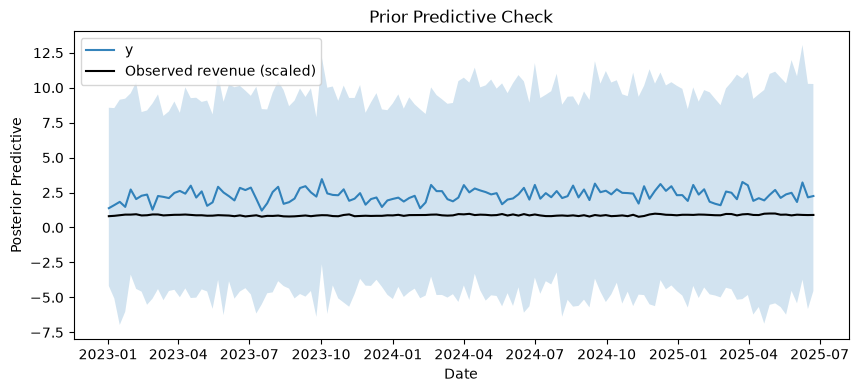

In [16]:
fig, axes = mmm.plot.prior_predictive(hdi_prob=0.94)

ax = axes.flatten()[0]

ax.plot(
    X_train["date_week"],
    y_train / y_train.max(),
    color="black",
    linewidth=1.5,
    label="Observed revenue (scaled)",
)

ax.set_title("Prior Predictive Check")
ax.legend()

The observed revenue falls within the prior predictive interval, but the default priors are quite broad and allow implausibly negative and very large outcomes.

In [18]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1000,
    draws=1000,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.
There were 22 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

In [19]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=1000,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 81 seconds.
There were 33 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

In [20]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=1500,
    draws=500,
    target_accept=0.99,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 1_500 tune and 500 draw iterations (6_000 + 2_000 draws total) took 105 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data

Increasing target_accept from 0.95 to 0.99 substantially reduced the divergence rate, but four post-warmup divergences remained, so the sampling configuration still required refinement.

In [21]:
mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    tune=2000,
    draws=1000,
    target_accept=0.995,
    random_seed=RANDOM_SEED,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 220 seconds.
There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data
	> fit_data